# Chapter 19 & 20: Market Microstructure

**AFML Ch. 19-20** -- Liquidity, price impact, and informed trading metrics.

Market microstructure features quantify the interaction between order flow, liquidity,
and price formation. These metrics are critical for understanding transaction costs,
detecting informed trading, and measuring market quality.

**Topics covered:**

- Tick rule classification
- VPIN (Volume-Synchronized Probability of Informed Trading)
- Amihud lambda (price impact)
- Kyle's lambda (order flow impact)
- Roll spread estimator
- Corwin-Schultz spread estimator
- Hasbrouck lambda (Gibbs sampling)
- Volatility estimators (Parkinson, Garman-Klass)
- Polars integration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import pymlfinance
import pymlfinance.polars
from pymlfinance.polars._lib import (
    amihud_lambda as pl_amihud, kyle_lambda as pl_kyle,
    corwin_schultz_spread as pl_cs, vpin as pl_vpin,
    parkinson_volatility as pl_parkinson,
    garman_klass_volatility as pl_gk,
    yang_zhang_volatility as pl_yz,
)

%matplotlib inline
np.random.seed(42)

## Generate Synthetic Trade Data

We simulate 2,000 trades with a simple microstructure model:

- An **efficient price** follows a random walk
- **Trade prices** include bid-ask bounce (the observed price jumps between bid and ask)
- **Volumes** are drawn from an exponential distribution
- **OHLC bars** are aggregated from the tick data for spread estimators

In [2]:
n = 2000
# Price with microstructure noise (bid-ask bounce)
efficient_price = 100.0 + np.cumsum(np.random.randn(n) * 0.05)
spread = 0.10
trade_prices = efficient_price + np.random.choice([-spread/2, spread/2], n)
volumes = np.abs(np.random.exponential(100, n))
dollar_volumes = trade_prices * volumes

# OHLC data (for spread estimators)
n_bars = 200
bar_size = n // n_bars
highs = np.array([trade_prices[i*bar_size:(i+1)*bar_size].max() for i in range(n_bars)])
lows = np.array([trade_prices[i*bar_size:(i+1)*bar_size].min() for i in range(n_bars)])
opens = np.array([trade_prices[i*bar_size] for i in range(n_bars)])
closes = np.array([trade_prices[(i+1)*bar_size - 1] for i in range(n_bars)])

print(f"Generated {n} trades, {n_bars} OHLC bars")
print(f"  Price range: {trade_prices.min():.2f} - {trade_prices.max():.2f}")
print(f"  True spread: {spread:.2f}")

Generated 2000 trades, 200 OHLC bars
  Price range: 99.12 - 104.82
  True spread: 0.10


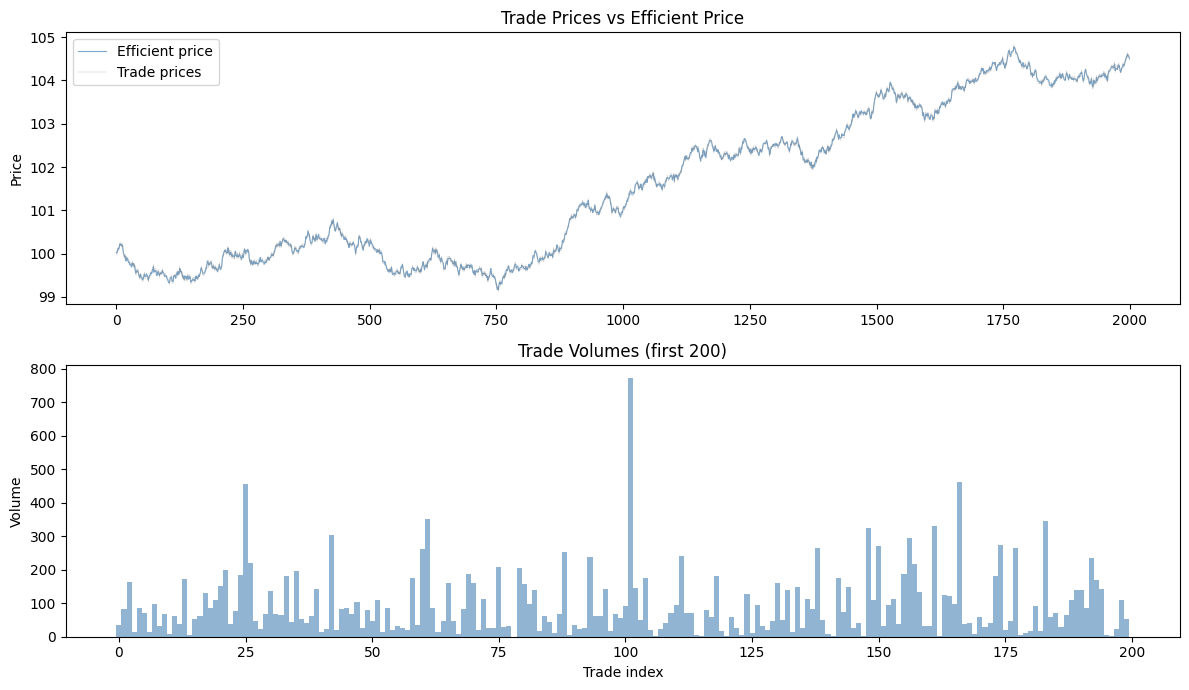

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(efficient_price, color="steelblue", linewidth=0.8, alpha=0.7, label="Efficient price")
axes[0].plot(trade_prices, color="gray", linewidth=0.3, alpha=0.5, label="Trade prices")
axes[0].set_ylabel("Price")
axes[0].set_title("Trade Prices vs Efficient Price")
axes[0].legend()

axes[1].bar(range(min(200, len(volumes))), volumes[:200], color="steelblue", alpha=0.6, width=1.0)
axes[1].set_xlabel("Trade index")
axes[1].set_ylabel("Volume")
axes[1].set_title("Trade Volumes (first 200)")

plt.tight_layout()
plt.show()

## Tick Rule Classification

The tick rule classifies each trade as buyer- or seller-initiated based on
price changes:

- **Uptick** (+1): price increased from previous trade (buyer-initiated)
- **Downtick** (-1): price decreased (seller-initiated)
- **No change** (0): same price as previous trade

In [4]:
tick_signs = pymlfinance.features.tick_rule_classify(trade_prices)
print(f"--- Tick Rule Classification ---")
print(f"  Upticks (+1): {np.sum(tick_signs > 0)}")
print(f"  Downticks (-1): {np.sum(tick_signs < 0)}")
print(f"  No change (0): {np.sum(tick_signs == 0)}")
print(f"  Buy/sell imbalance: {np.mean(tick_signs):.4f}")

--- Tick Rule Classification ---
  Upticks (+1): 1045
  Downticks (-1): 954
  No change (0): 1
  Buy/sell imbalance: 0.0455


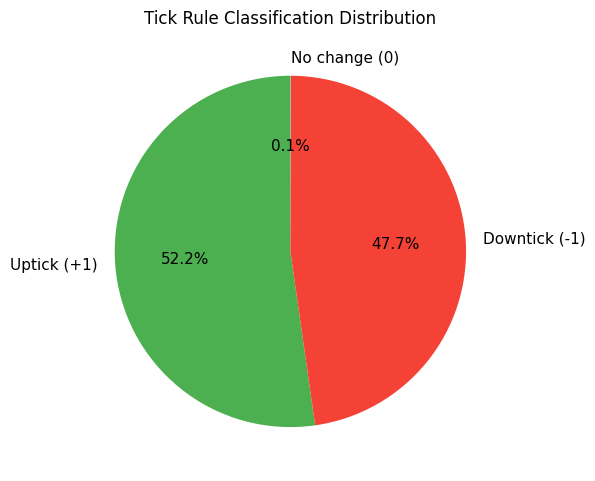

In [5]:
# Tick classification pie chart
tick_counts = [np.sum(tick_signs > 0), np.sum(tick_signs < 0), np.sum(tick_signs == 0)]
tick_labels = ["Uptick (+1)", "Downtick (-1)", "No change (0)"]
tick_colors = ["#4CAF50", "#F44336", "#9E9E9E"]

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    tick_counts, labels=tick_labels, colors=tick_colors,
    autopct="%1.1f%%", startangle=90, textprops={"fontsize": 11}
)
ax.set_title("Tick Rule Classification Distribution")
plt.tight_layout()
plt.show()

## VPIN (Volume-Synchronized Probability of Informed Trading)

VPIN estimates the fraction of trading volume that comes from informed traders.
It partitions trading activity into equal-volume buckets and measures the
buy/sell imbalance within each bucket. Higher VPIN values indicate more
informed trading (potential adverse selection).

In [6]:
vpin_values = pymlfinance.features.vpin(
    volumes=volumes, prices=trade_prices,
    bucket_size=float(np.sum(volumes) / 100),  # ~100 buckets
    n_buckets=10
)
print(f"--- VPIN ---")
print(f"  VPIN series length: {len(vpin_values)}")
if len(vpin_values) > 0:
    print(f"  Mean VPIN: {np.mean(vpin_values):.4f}")
    print(f"  Max VPIN:  {np.max(vpin_values):.4f}")
    print(f"  Min VPIN:  {np.min(vpin_values):.4f}")

--- VPIN ---
  VPIN series length: 86
  Mean VPIN: 0.2487
  Max VPIN:  0.3856
  Min VPIN:  0.0894


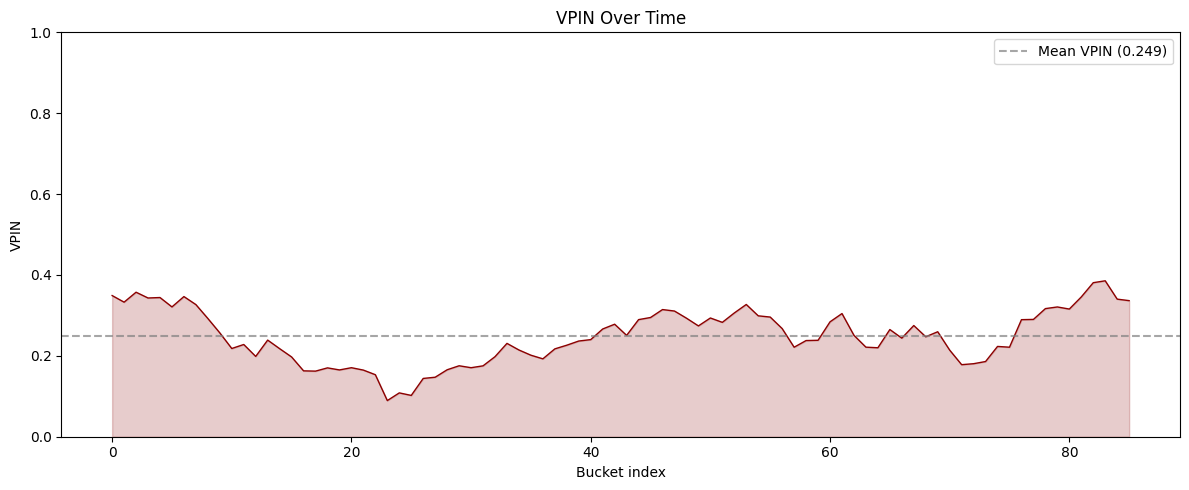

In [7]:
if len(vpin_values) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(vpin_values, color="darkred", linewidth=1)
    ax.axhline(y=np.mean(vpin_values), color="gray", linestyle="--", alpha=0.7,
               label=f"Mean VPIN ({np.mean(vpin_values):.3f})")
    ax.fill_between(range(len(vpin_values)), vpin_values, alpha=0.2, color="darkred")
    ax.set_xlabel("Bucket index")
    ax.set_ylabel("VPIN")
    ax.set_title("VPIN Over Time")
    ax.legend()
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

## Price Impact: Amihud Lambda

Amihud's illiquidity measure (lambda) captures the average price impact per unit of
dollar volume traded. Higher values indicate less liquid markets where trading has
a larger impact on prices.

$$\lambda_{Amihud} = \frac{1}{N} \sum_t \frac{|r_t|}{V_t^\$}$$

In [8]:
returns = pymlfinance.core.log_returns(trade_prices)
amihud = pymlfinance.features.amihud_lambda(returns, dollar_volumes[1:])
print(f"--- Amihud Lambda (Price Impact) ---")
print(f"  Amihud lambda: {amihud:.8f}")
print(f"  (Higher = less liquid / greater price impact)")

# Rolling Amihud
amihud_rolling = pymlfinance.features.amihud_lambda_rolling(returns, dollar_volumes[1:], window=100)
print(f"  Rolling Amihud (window=100): mean={np.nanmean(amihud_rolling):.8f}")

--- Amihud Lambda (Price Impact) ---
  Amihud lambda: 0.00000322
  (Higher = less liquid / greater price impact)
  Rolling Amihud (window=100): mean=0.00000337


## Kyle's Lambda

Kyle's lambda measures the permanent price impact of order flow. It is estimated
from the regression of returns on signed (buy/sell) volume. Higher lambda implies
that trades carry more information about fundamental value.

In [9]:
signed_vol = tick_signs[1:].astype(np.float64) * volumes[1:]
kyle = pymlfinance.features.kyle_lambda(returns, signed_vol)
print(f"--- Kyle Lambda ---")
print(f"  Kyle lambda: {kyle:.8f}")
print(f"  (Permanent price impact per unit signed volume)")

--- Kyle Lambda ---
  Kyle lambda: 0.00000345
  (Permanent price impact per unit signed volume)


## Spread Estimators

Spread estimators infer the bid-ask spread from observed prices without needing
the actual order book. We compare two approaches:

- **Roll spread**: Uses the negative autocovariance of returns (works with close prices)
- **Corwin-Schultz spread**: Uses high-low price ratios across adjacent bars

In [10]:
roll = pymlfinance.features.roll_spread(closes)
print(f"--- Roll Spread Estimator ---")
print(f"  Estimated spread: {roll:.4f}")
print(f"  True spread: {spread:.4f}")
print(f"  Error: {abs(roll - spread):.4f}")

# Rolling Roll
roll_rolling = pymlfinance.features.roll_spread_rolling(closes, window=20)
print(f"  Rolling mean: {np.nanmean(roll_rolling):.4f}")

--- Roll Spread Estimator ---
  Estimated spread: 0.0968
  True spread: 0.1000
  Error: 0.0032
  Rolling mean: 0.1080


In [11]:
cs_spread = pymlfinance.features.corwin_schultz_spread(highs, lows)
print(f"--- Corwin-Schultz Spread ---")
cs_valid = cs_spread[~np.isnan(cs_spread)]
if len(cs_valid) > 0:
    print(f"  Mean spread: {np.mean(cs_valid):.4f}")
    print(f"  Median spread: {np.median(cs_valid):.4f}")

--- Corwin-Schultz Spread ---
  Mean spread: 0.0006
  Median spread: 0.0004


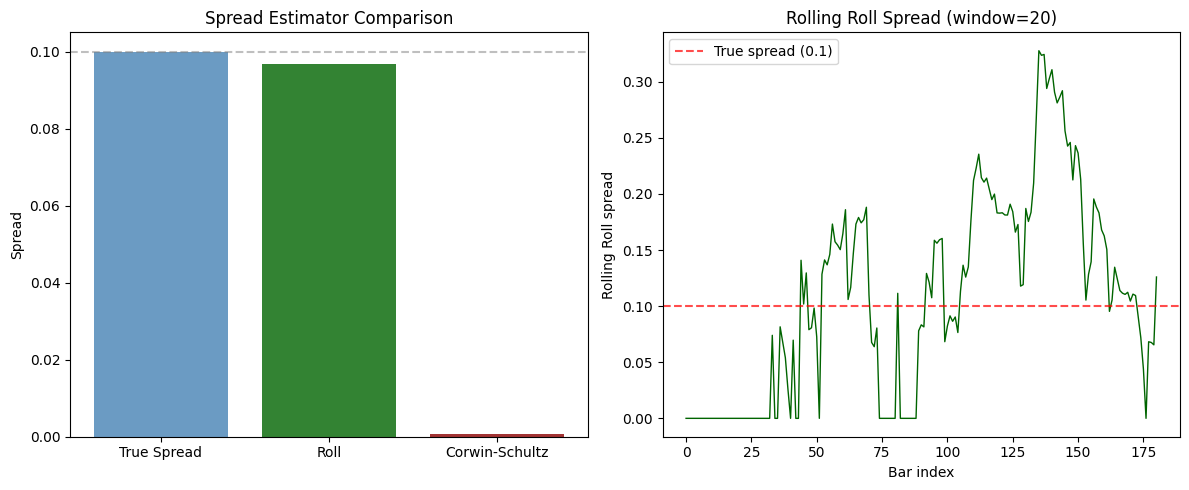

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Spread estimator comparison bar chart
spread_names = ["True Spread", "Roll", "Corwin-Schultz"]
spread_values = [spread, roll, np.nanmean(cs_valid) if len(cs_valid) > 0 else 0]
bar_colors = ["steelblue", "darkgreen", "darkred"]
axes[0].bar(spread_names, spread_values, color=bar_colors, alpha=0.8)
axes[0].axhline(y=spread, color="gray", linestyle="--", alpha=0.5)
axes[0].set_ylabel("Spread")
axes[0].set_title("Spread Estimator Comparison")

# Rolling Roll spread over time
valid_mask = ~np.isnan(roll_rolling)
roll_x = np.arange(len(roll_rolling))
axes[1].plot(roll_x[valid_mask], roll_rolling[valid_mask], color="darkgreen", linewidth=1)
axes[1].axhline(y=spread, color="red", linestyle="--", alpha=0.7, label=f"True spread ({spread})")
axes[1].set_xlabel("Bar index")
axes[1].set_ylabel("Rolling Roll spread")
axes[1].set_title("Rolling Roll Spread (window=20)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Hasbrouck Lambda (Gibbs Sampling)

Hasbrouck's lambda decomposes price changes into permanent (information) and
transitory (noise) components using a Bayesian Gibbs sampling approach.
This provides a more robust estimate of information-driven price impact.

In [13]:
trade_signs = tick_signs[1:].astype(np.float64)
# Replace zeros with previous sign
for i in range(1, len(trade_signs)):
    if trade_signs[i] == 0:
        trade_signs[i] = trade_signs[i-1]
hasbrouck = pymlfinance.features.hasbrouck_lambda(returns, trade_signs, n_iterations=100, seed=42)
print(f"--- Hasbrouck Lambda (Gibbs Sampling) ---")
print(f"  Hasbrouck lambda: {hasbrouck:.8f}")

--- Hasbrouck Lambda (Gibbs Sampling) ---
  Hasbrouck lambda: 0.00067728


## Polars API

All microstructure metrics are available through the Polars expression API.
Single-column functions use the `.ml` namespace, while multi-column functions
(like volatility estimators) are called as standalone expressions.

In [14]:
# Tick-level Polars
tick_df = pl.DataFrame({
    "price": trade_prices,
    "volume": volumes,
})
tick_result = tick_df.with_columns(
    pl.col("price").ml.tick_rule_classify().alias("tick_sign"),
)
print(f"  Tick signs (first 5): {tick_result['tick_sign'].head(5).to_list()}")

  Tick signs (first 5): [0.0, -1.0, 1.0, -1.0, -1.0]


In [15]:
# Bar-level Polars
bar_returns = np.concatenate([[np.nan], pymlfinance.core.log_returns(closes)])
bar_dollar_vol = closes * volumes[:n_bars]
bar_df = pl.DataFrame({
    "open": opens, "high": highs, "low": lows, "close": closes,
    "returns": bar_returns,
    "dollar_volume": bar_dollar_vol,
})

# Multi-column functions
parkinson = bar_df.with_columns(
    pl_parkinson(pl.col("high"), pl.col("low"), window=20).alias("parkinson_vol"),
)
print(f"  Parkinson vol (first non-null): "
      f"{parkinson['parkinson_vol'].drop_nulls().head(3).to_list()}")

gk = bar_df.with_columns(
    pl_gk(pl.col("open"), pl.col("high"), pl.col("low"), pl.col("close"), window=20).alias("gk_vol"),
)
print(f"  Garman-Klass vol (first non-null): "
      f"{gk['gk_vol'].drop_nulls().head(3).to_list()}")

  Parkinson vol (first non-null): [nan, nan, nan]
  Garman-Klass vol (first non-null): [nan, nan, nan]


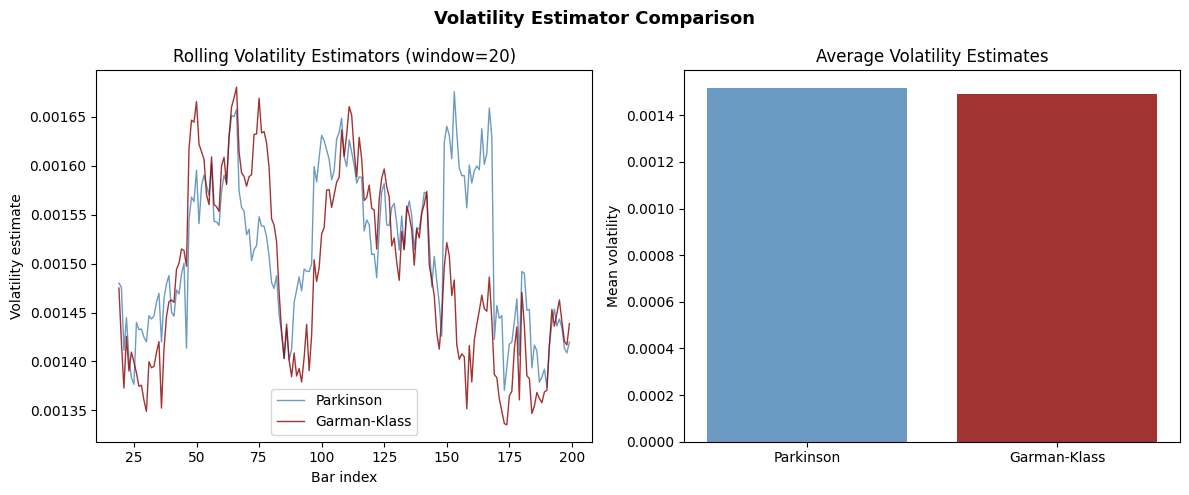

In [16]:
# Volatility estimator comparison
park_vals = parkinson["parkinson_vol"].drop_nulls().to_numpy()
gk_vals = gk["gk_vol"].drop_nulls().to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Time series comparison
axes[0].plot(park_vals, color="steelblue", linewidth=1, alpha=0.8, label="Parkinson")
axes[0].plot(gk_vals, color="darkred", linewidth=1, alpha=0.8, label="Garman-Klass")
axes[0].set_xlabel("Bar index")
axes[0].set_ylabel("Volatility estimate")
axes[0].set_title("Rolling Volatility Estimators (window=20)")
axes[0].legend()

# Bar chart of means
vol_names = ["Parkinson", "Garman-Klass"]
vol_means = [np.nanmean(park_vals), np.nanmean(gk_vals)]
axes[1].bar(vol_names, vol_means, color=["steelblue", "darkred"], alpha=0.8)
axes[1].set_ylabel("Mean volatility")
axes[1].set_title("Average Volatility Estimates")

plt.suptitle("Volatility Estimator Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Exercises

1. **Spread tracking** -- Increase the true spread (e.g., to 0.20 or 0.50) and verify that the Roll and Corwin-Schultz estimators track it. How accurate are they at different spread levels?

2. **Informed trading** -- Add directional volume (e.g., make 70% of trades buyer-initiated during a particular period) and observe whether VPIN increases in that region.

3. **Liquidity regimes** -- Compare Amihud and Kyle lambdas under different liquidity conditions by varying the volume distribution (e.g., high vs low average volume periods).